# The Last Hike \U0001F3DB
### Everyone waits for the Fed to stop. Nobody knows when it has.

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)

The chart everyone shows is real: after the Fed's final hike, markets do well. The chart nobody
shows is what a person standing on that date could have known — which is nothing, because "final
hike" is a label the future assigns.

> \U0001F4D3 **This is the plain-language layer.** The base-rate adjustment, the live rule and
> the planted-effect control are in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** Every chart below is generated by the code beside it.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))   # repo root (quantlab/ lives there)
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

## The answer first \U0001F3AF

| Question | Answer |
|---|---|
| Do markets do well after the last hike? | Yes — but they do well after most dates too. |
| Is the excess over that base rate large? | Positive; with five cycles, not measurable. |
| Could you have known it was the last hike? | No. Not for at least six months. |
| What does the waiting cost? | Most of the move. |

## 1 · Five cycles. That's the whole sample.

In [2]:
from lasthike import data, strategy as st

px = data.load_prices()
eq = px[data.EQUITY].dropna()
path = st.policy_path()
cycles = st.tightening_cycles(path)
print(f"as-of {data.AS_OF} | {len(path)} target changes since {path.index[0].date()}")
print(cycles.assign(first_hike=cycles["first_hike"].dt.date,
                    last_hike=cycles["last_hike"].dt.date).round(2).to_string(index=False))

as-of 2026-06-30 | 88 target changes since 1994-02-04
first_hike  last_hike  n_hikes  months  total_tightening
1994-02-04 1995-02-01        7 11.8900            2.7500
1999-06-30 2000-05-16        6 10.5500            1.5000
2004-06-30 2006-06-29       17 23.9500            4.0000
2015-12-16 2018-12-19        9 36.1000            2.0000
2022-03-17 2023-07-26       11 16.2900            5.0000


Everything that follows rests on those five rows. No amount of daily data makes them six.

## 2 · The chart everyone shows

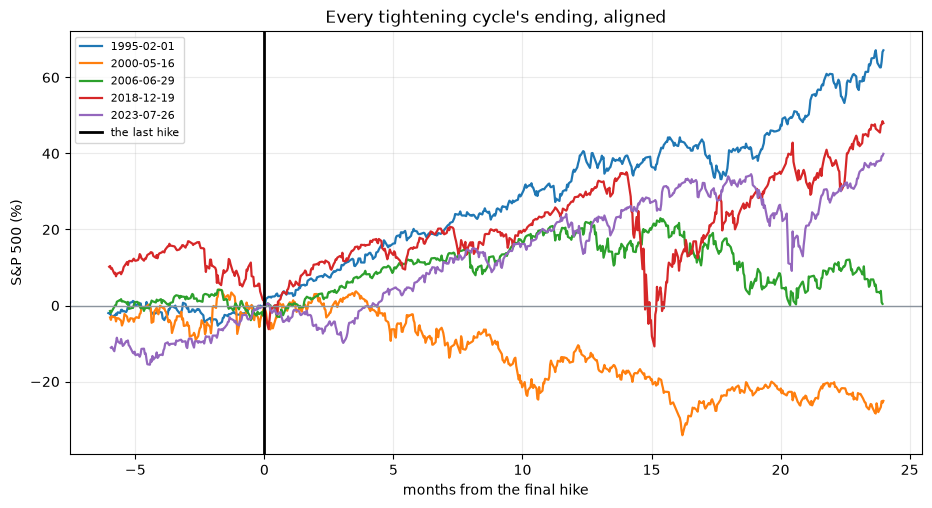

In [3]:
fig, ax = plt.subplots(figsize=(11, 5.5))
for _, c in cycles.iterrows():
    d = c["last_hike"]
    sl = eq.loc[d - pd.DateOffset(months=6):d + pd.DateOffset(months=24)]
    if len(sl) < 100:
        continue
    base = float(eq.loc[:d].iloc[-1])
    x = [(t - d).days / 30.44 for t in sl.index]
    ax.plot(x, (sl / base - 1) * 100, lw=1.6, label=str(d.date()))
ax.axvline(0, color="k", lw=2, label="the last hike")
ax.axhline(0, color="#8b949e", lw=1)
ax.set_xlabel("months from the final hike"); ax.set_ylabel("S&P 500 (%)")
ax.legend(fontsize=8)
ax.set_title("Every tightening cycle's ending, aligned")
plt.show()

> \U0001F52C **For the quants.** Note the dispersion. 2000 and 2006 were followed by recessions;
> 1995 and 2023 were not. Averaging these five paths assumes they are draws from one
> distribution, which is a strong assumption about five very different macroeconomic episodes.

## 3 · Against the base rate

Stocks go up. The question is whether they go up *more* than usual.

           n_events  event_mean  event_median  base_mean  excess      t  hit_rate
horizon_m                                                                        
3                 5      0.0376        0.0495     0.0250  0.0126 0.3822    0.8000
6                 5      0.0957        0.1143     0.0482  0.0474 1.0073    0.8000
12                5      0.1778        0.1954     0.1006  0.0772 1.0824    0.8000
24                5      0.2607        0.3989     0.2091  0.0516 0.4575    0.8000


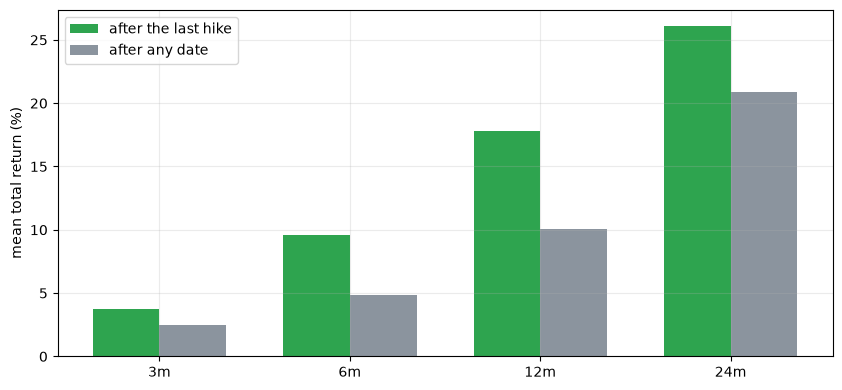

In [4]:
tbl = st.event_table(eq, list(cycles["last_hike"]))
print(tbl.round(4).to_string())
fig, ax = plt.subplots(figsize=(10, 4.5))
w = 0.35
xs = np.arange(len(tbl))
ax.bar(xs - w / 2, tbl["event_mean"] * 100, w, label="after the last hike", color="#2ea44f")
ax.bar(xs + w / 2, tbl["base_mean"] * 100, w, label="after any date", color="#8b949e")
ax.set_xticks(xs); ax.set_xticklabels([f"{int(m)}m" for m in tbl.index])
ax.set_ylabel("mean total return (%)"); ax.legend()
plt.show()

## 4 · The part nobody charts

You did not know. Here is the most generous rule available to someone who could not see the
future: wait six months with no hike, then call it.

In [5]:
fa = st.false_alarms(path, quiet_months=6)
print(fa.assign(signal_date=fa["signal_date"].dt.date,
                after_hike=fa["after_hike"].dt.date).to_string(index=False))
print(f"\n{len(fa)} signals, of which {int((~fa['was_the_end']).sum())} were false alarms "
      f"({1 - fa['was_the_end'].mean():.0%})")

signal_date after_hike  was_the_end  next_hike
 1995-08-01 1995-02-01        False 1997-03-25
 1997-09-25 1997-03-25        False 1999-06-30
 2000-11-16 2000-05-16         True 2004-06-30
 2006-12-29 2006-06-29         True 2015-12-16
 2016-06-16 2015-12-16        False 2016-12-14
 2019-06-19 2018-12-19         True 2022-03-17
 2024-01-26 2023-07-26         True        NaT

7 signals, of which 3 were false alarms (43%)


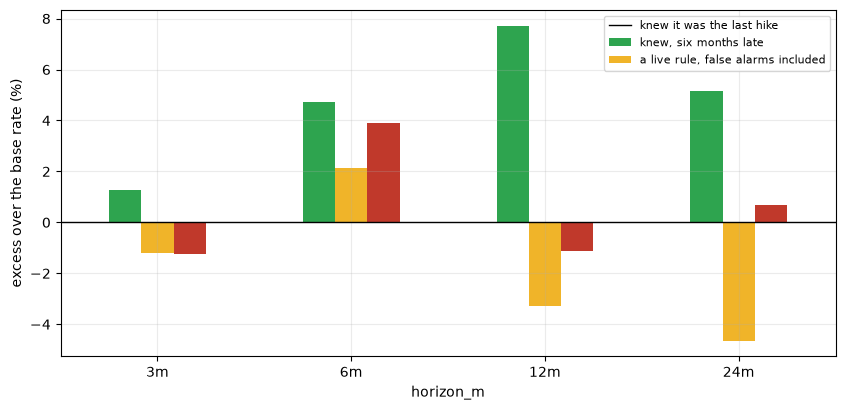

,hindsight_excess,hindsight_t,delayed_excess,delayed_t,live_excess,live_t,n_hindsight,n_live
horizon_m,,,,,,,,
3,0.0126,0.3822,-0.0119,-0.3637,-0.0123,-0.4423,5,7
6,0.0474,1.0073,0.0215,0.4564,0.0389,0.9782,5,7
12,0.0772,1.0824,-0.0326,-0.4577,-0.0114,-0.1885,5,7
24,0.0516,0.4575,-0.0465,-0.4124,0.0070,0.0735,5,7


In [6]:
cmp = st.hindsight_vs_realtime(eq, cycles, path, quiet_months=6)
fig, ax = plt.subplots(figsize=(10, 4.5))
cmp[["hindsight_excess", "delayed_excess", "live_excess"]].mul(100).plot.bar(
    ax=ax, color=["#2ea44f", "#f0b429", "#c0392b"])
ax.axhline(0, color="k", lw=1)
ax.set_ylabel("excess over the base rate (%)")
ax.set_xticklabels([f"{int(m)}m" for m in cmp.index], rotation=0)
ax.legend(["knew it was the last hike", "knew, six months late",
           "a live rule, false alarms included"], fontsize=8)
plt.show()
cmp.round(4)

## 5 · What the waiting cost

In [7]:
wd = st.what_the_delay_costs(eq, cycles, quiet_months=6)
print(wd.round(4).to_string())
print(f"\nmedian given up while waiting: {wd['missed_return'].median():+.1%}")

                 acted  missed_return
last_hike                            
1995-02-01  1995-08-01         0.1897
2000-05-16  2000-11-16        -0.0639
2006-06-29  2006-12-29         0.1143
2018-12-19  2019-06-19         0.1673
2023-07-26  2024-01-26         0.0710

median given up while waiting: +11.4%


## 6 · The verdict

**Signal: Weak.** Across the **5 tightening cycles** since the Fed began announcing its target in 1994, the S&P returned **+17.8%** in the twelve months after the cycle's true final hike, against an unconditional base rate of +10.1% — an excess of **+7.7%** (*t* = **+1.08**, 80% of cycles positive). With 5 events there is no *t*-statistic that can carry much weight, and the study says so rather than dressing eight observations as a finding.

**Tradability: Mirage.** None of that is available at the time. Nobody knew 2023-07-26 was the last hike until months of not-hiking had passed. A live rule — declare the cycle over after **6 quiet months** — fired 7 times, of which **43% were false alarms** (another hike followed within two years), and earned an excess of **-1.1%** at twelve months (*t* = -0.19) against the hindsight version's +7.7%. The delay alone gave up a median **+11.4%** between the true last hike and the day the rule could act — 64% of the whole twelve-month move.

## 7 · Going further \U0001F6AA

- **Use the market's own expectation.** Fed funds futures price the odds of another hike; a rule
  built on those would recognise the ending faster than "six quiet months".
- **Condition on why the cycle ended.** A pause because inflation fell is not a pause because
  something broke — and the two are followed by very different years.
- **Other central banks** multiply the sample from five cycles to perhaps thirty, at the cost of
  pooling very different economies.